<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/Diabetes_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Diabetes Risk Prediction (Binary Classification)

Neural Network Architecture:

2 Inputs → 3 Hidden Neurons (Sigmoid) → 1 Output (Sigmoid)

Output = 1 → High Risk
Output = 0 → Low Risk


In [ ]:
import numpy as np

np.random.seed(0)

X=np.array([
    [120,85,150,95], #Glucode
    [25,30,35,22]    # BMI
])

#Normalize Values
X=X/200

#Output : 1=High Risk, 0=Low Risk
Y=np.array([[1,0,1,0]])

print("X Shape:",X.shape)
print("Y Shape:",Y.shape)

X Shape: (2, 4)
Y Shape: (1, 4)


## Sigmoid Function

In [ ]:
def sigmoid(Z):
  return 1/(1+np.exp(-Z))

#Initialize Parameters

In [ ]:
#Hidden Layer(3 neurons,2 inputs)
w1=np.random.randn(3,2)*0.1
b1=np.zeros((3,1))
#Output Layer(1 neuron,3 hidden inputs)
w2=np.random.randn(1,3)*0.1
b2=np.zeros((1,1))

#Forward Propagation

In [ ]:
#Hidden Layer
z1=np.dot(w1,X)+b1
a1=sigmoid(z1)

#Output Layer
z2=np.dot(w2,a1)+b2
a2=sigmoid(z2)

print("Predicted Output:")
print(a2)

Predicted Output:
[[0.50920404 0.50906064 0.50933304 0.50909873]]


#Loss Function
Binary Cross Entropy

In [ ]:
m=Y.shape[1]
loss=-np.sum(Y*np.log(a2+1e-8)+(1-Y)*np.log(1-a2+1e-8))/m
print("Loss:",loss)

Loss: 0.693126613708025


#Back Propagation
Output Layer Gradient

In [ ]:
dZ2=a2-Y
dW2=(1/m)*np.dot(dZ2,a1.T)
db2=(1/m)*np.sum(dZ2,axis=1,keepdims=True)

#Hidden Layer Gradient

Sigmoid derivative:

In [ ]:
dA1=np.dot(w2.T,dZ2)
dZ1=dA1*a1*(1-a1)

dW1=(1/m)*np.dot(dZ1,X.T)
db1=(1/m)*np.sum(dZ1,axis=1,keepdims=True)

# Update Parameters

In [ ]:
learning_rate=0.5
w2-=learning_rate*dW2
b2=learning_rate*db2

w1-=learning_rate*dW1
b1-=learning_rate*db1

#Complete Trainng Loop

In [ ]:
epoch=5000
for i in range(epoch):
  #Forward
  Z1=np.dot(w1,X)+b1
  A1=sigmoid(Z1)

  Z2=np.dot(w2,A1)+b2
  A2=sigmoid(Z2)
  #loss
  loss=-np.sum(Y*np.log(A2+1e-8)+(1-Y)*np.log(1-A2+1e-8))/m
  #Backward
  dZ2=A2-Y
  dW2=(1/m)*np.dot(dZ2,A1.T)
  db2=(1/m)*np.sum(dZ2,axis=1,keepdims=True)

  dA1=np.dot(w2.T,dZ2)
  dZ1=dA1*A1*(1-A1)

  dw1=(1/m)*np.dot(dZ1,X.T)
  db1=(1/m)*np.sum(dZ1,axis=1,keepdims=True)
  #Update
  w2-= 0.5*dW2
  b2-=0.5*db2
  w1-= 0.5*dW1
  b1-=0.5*db1
  if i%100==0:
    print("Epoch:",i,"Loss:",loss)


Epoch: 0 Loss: 0.24897366894560222
Epoch: 100 Loss: 0.23126503894478728
Epoch: 200 Loss: 0.20920037224168087
Epoch: 300 Loss: 0.17870796323703175
Epoch: 400 Loss: 0.15092525398295908
Epoch: 500 Loss: 0.14148270671636803
Epoch: 600 Loss: 0.1350258760451697
Epoch: 700 Loss: 0.1289177832206801
Epoch: 800 Loss: 0.12310138593147935
Epoch: 900 Loss: 0.1175608971725669
Epoch: 1000 Loss: 0.11228200231374968
Epoch: 1100 Loss: 0.10725148658768824
Epoch: 1200 Loss: 0.10245702193179757
Epoch: 1300 Loss: 0.09788703852170098
Epoch: 1400 Loss: 0.09353063651569397
Epoch: 1500 Loss: 0.08937751922201911
Epoch: 1600 Loss: 0.08541793940097239
Epoch: 1700 Loss: 0.08164265464034064
Epoch: 1800 Loss: 0.07804288952822927
Epoch: 1900 Loss: 0.07461030316154774
Epoch: 2000 Loss: 0.07133696094397053
Epoch: 2100 Loss: 0.06821530987128986
Epoch: 2200 Loss: 0.06523815666631089
Epoch: 2300 Loss: 0.062398648247847896
Epoch: 2400 Loss: 0.059690254115287666
Epoch: 2500 Loss: 0.05710675030925658
Epoch: 2600 Loss: 0.05464

# **Diabets risk prediction using tensorflow**

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
X = np.array([
    [120,25],
    [85,30],
    [150,35],
    [95,22]
])
X=X/200
y =np.array([[1,0,1,0]]).reshape(4,1)
print("Input Shape:",X.shape)
print("Output Shape:",y.shape)
model = Sequential([
    Dense(3,input_shape=(2,),activation='sigmoid'),  #Hidden Layer
    Dense(1,activation='sigmoid') #Output Layer
])
model.summary()
model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X ,y,epochs=500,verbose=0)

Input Shape: (4, 2)
Output Shape: (4, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
pred=model.predict(X)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[0.49512315],
       [0.5110272 ],
       [0.48196152],
       [0.5064545 ]], dtype=float32)

# **predict with folwers species an iris belongs to:**

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import argmax
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
iris=load_iris()
x=iris.data
y=iris.target
target_names=iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
model=Sequential()
model.add(Dense(10,activation='relu',input_shape=(x_train.shape[1],)))
model.add(Dense(5,activation='relu'))
model.add(Dense(3,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=50,batch_size=8,validation_split=0.1,verbose=1)
#

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.8728 - loss: 0.3084 - val_accuracy: 0.9167 - val_loss: 0.4156
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8984 - loss: 0.2581 - val_accuracy: 0.9167 - val_loss: 0.4049
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8858 - loss: 0.2758 - val_accuracy: 0.9167 - val_loss: 0.3994
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9562 - loss: 0.2634 - val_accuracy: 0.9167 - val_loss: 0.3830
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9170 - loss: 0.2549 - val_accuracy: 0.9167 - val_loss: 0.3708
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9166 - loss: 0.2461 - val_accuracy: 0.9167 - val_loss: 0.3622
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8713 - loss: 0.2657 - val_accuracy: 0.9167 - val_loss: 0.3617
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9107 - loss: 0.2218 - val_accuracy: 0.9167 - v

In [ ]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print('Test Accuracy:',test_acc)
print('Test Loss:',test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9667 - loss: 0.0687
Test Accuracy: 0.9666666388511658
Test Loss: 0.06871531903743744


In [ ]:
pred_prob=model.predict(x_test)
pred_class=argmax(pred_prob,axis=1)
print('Predicted Class:',pred_class)
#

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
Predicted Class: tf.Tensor([1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0], shape=(30,), dtype=int64)


In [ ]:
accuracy_score(y_test,pred_class)
#

0.9666666666666667

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/CarPrice_dataset.csv")

In [ ]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [ ]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
# Convert textual numbers to numeric

door_map = {
    "two": 2,
    "four": 4
}

cylinder_map = {
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
}

df['doornumber'] = df['doornumber'].map(door_map)
df['cylindernumber'] = df['cylindernumber'].map(cylinder_map)

# Check updated data types
print(df.dtypes)

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber            int64
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber        int64
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object


In [ ]:
# Extract brand name
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0])

# Drop original CarName column
df.drop('CarName', axis=1, inplace=True)

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:", categorical_cols)

# One Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.head())

Categorical Columns: Index(['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation',
       'enginetype', 'fuelsystem', 'brand'],
      dtype='object')
   car_ID  symboling  doornumber  wheelbase  carlength  carwidth  carheight  \
0       1          3           2       88.6      168.8      64.1       48.8   
1       2          3           2       88.6      168.8      64.1       48.8   
2       3          1           2       94.5      171.2      65.5       52.4   
3       4          2           4       99.8      176.6      66.2       54.3   
4       5          2           4       99.4      176.6      66.4       54.3   

   curbweight  cylindernumber  enginesize  ...  brand_porsche  brand_renault  \
0        2548               4         130  ...          False          False   
1        2548               4         130  ...          False          False   
2        2823               6         152  ...          False          False   
3        2337               4         109

In [ ]:
X = df.drop('price', axis=1)

y = df['price']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (164, 66)
Testing data shape: (41, 66)


# **buliding fnn model**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Get number of input features
input_features = X_train.shape[1]

# Create model
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(input_features,)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 96674744.0000 - mae: 8724.7402 - val_loss: 140064016.0000 - val_mae: 10255.5117
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 91903464.0000 - mae: 8458.6602 - val_loss: 136751024.0000 - val_mae: 10134.2656
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 75037576.0000 - mae: 7759.5635 - val_loss: 133490920.0000 - val_mae: 10013.3867
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 82381784.0000 - mae: 8106.9609 - val_loss: 130099888.0000 - val_mae: 9886.0146
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 82534312.0000 - mae: 8128.0571 - val_loss: 126959920.0000 - val_mae: 9764.5615
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 73294520.0000 - mae: 7742.1021 - val_loss: 123795808.0000 - val_mae: 9640.2236
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 77017752.0000 - mae: 7720.6299 - val_loss: 120351072.0000 - val_mae: 9504.3057
Epoch 8/1000
5/5 ━━━━━━━━━━━━━

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7036193.0000 - mae: 1741.9177
Test Loss: 6627034.0
Test MAE: 1673.4268798828125


In [ ]:
predictions = model.predict(X_test)

print(predictions[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[30421.299 ]
 [20788.092 ]
 [ 7567.4146]
 [15019.919 ]
 [27802.646 ]]


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,predictions)

0.9160540166188074

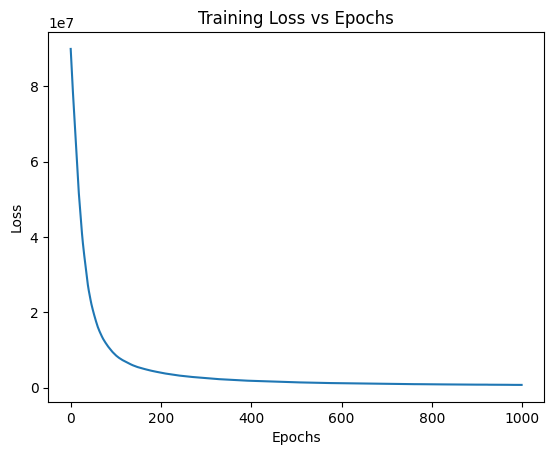

In [ ]:
import matplotlib.pyplot as plt

# Plot Training Loss
plt.plot(history.history['loss'])

plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

In [ ]:
import pandas as pd

new_car = {
    'enginesize': 1800,
    'citympg': 15,
}
new_car_df = pd.DataFrame([new_car])
new_car_df = new_car_df.reindex(columns=X.columns, fill_value=0)
new_car_scaled = scaler.transform(new_car_df)
predicted_price = model.predict(new_car_scaled)

print("Predicted Price = ₹", predicted_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
Predicted Price = ₹ 13572.724
